# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

**Objective:** Investigate how different spatial-domain image-processing filters affect the performance of pretrained deep-learning models for skin-lesion classification, using the HAM10000 dataset.

**Models used (top 3 from Lab Activity 1, by F1-score / AUC):** `vgg16`, `efficientnet_b0`, `resnet50`
**Filters applied:** Average/Mean, Gaussian, Median, Sharpening, Sobel edge, plus an unfiltered baseline — 18 (model × filter) runs total.


In [1]:
!pip install -q timm kagglehub

import os, glob, random, time, json, pickle
import numpy as np
import pandas as pd

# Image processing
import cv2
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

# Metrics & viz
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                              balanced_accuracy_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

RESULTS_DIR = "/content/drive/MyDrive/Lab2_CV_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Results will persist to:", RESULTS_DIR)


Mounted at /content/drive
Results will persist to: /content/drive/MyDrive/Lab2_CV_Results


In [3]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

# Index every image once (files live under two part-folders)
all_image_paths = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in glob.glob(os.path.join(path, "*", "*.jpg")) + glob.glob(os.path.join(path, "*.jpg"))
}

df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))
df["path"] = df["image_id"].map(all_image_paths.get)
df = df.dropna(subset=["path"]).reset_index(drop=True)

print(df["dx"].value_counts())   # class distribution — also used in Section 7
print("Total images:", len(df))


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Total images: 10015


In [4]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["dx"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df["dx"], random_state=SEED)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
# Save the split so every later experiment loads the SAME rows.
train_df.to_csv("split_train.csv", index=False)
val_df.to_csv("split_val.csv", index=False)
test_df.to_csv("split_test.csv", index=False)

CLASS_NAMES = sorted(df["dx"].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)


Train: 7010  Val: 1502  Test: 1503


In [5]:
class HAM10000Dataset(Dataset):
    """Applies an optional filter_fn (defined in Section 4) before the standard transform."""
    def __init__(self, dataframe, filter_fn=None, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.filter_fn = filter_fn
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.filter_fn is not None:
            image = self.filter_fn(image)

        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)

        label = CLASS_TO_IDX[row["dx"]]
        return image, label


In [6]:
def build_model(name, num_classes):
    # timm handles all three (vgg16, efficientnet_b0, resnet50) with the same call,
    # consistent with how they were loaded in the Lab 1 notebook.
    model = timm.create_model(name, pretrained=True, num_classes=num_classes)
    return model.to(device)

MODEL_NAMES = ["vgg16", "efficientnet_b0", "resnet50"]  # top 3 from Lab 1 (by F1-score / AUC)


In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def make_loaders(filter_fn=None, transform=base_transform):
    train_ds = HAM10000Dataset(train_df, filter_fn, transform)
    val_ds   = HAM10000Dataset(val_df,   filter_fn, transform)
    test_ds  = HAM10000Dataset(test_df,  filter_fn, transform)
    return (DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2),
            DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
            DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2))

baseline_train_loader, baseline_val_loader, baseline_test_loader = make_loaders(filter_fn=None)


In [8]:
def apply_mean_filter(img, ksize=5):
    return cv2.blur(img, (ksize, ksize))

def apply_gaussian_filter(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)

def apply_median_filter(img, ksize=5):
    return cv2.medianBlur(img, ksize)

def apply_sharpening_filter(img):
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)

def apply_sobel_filter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.uint8(255 * mag / (mag.max() + 1e-8))
    return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)

FILTERS = {
    "baseline":    None,
    "mean":        apply_mean_filter,
    "gaussian":    apply_gaussian_filter,
    "median":      apply_median_filter,
    "sharpening":  apply_sharpening_filter,
    "sobel":       apply_sobel_filter,
}


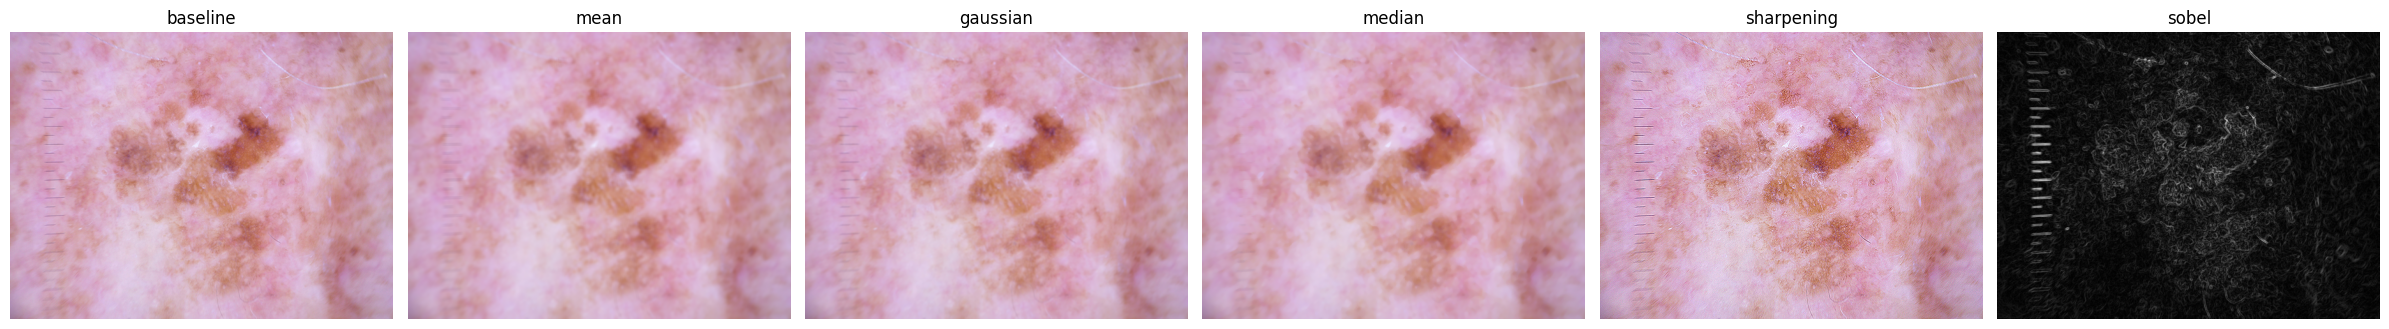

In [9]:
# Quick visual sanity check — original vs each filter, for Section 7 (Additional Analysis)
sample_img = cv2.cvtColor(cv2.imread(df.iloc[0]["path"]), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, len(FILTERS), figsize=(4*len(FILTERS), 4))
for ax, (name, fn) in zip(axes, FILTERS.items()):
    out = sample_img if fn is None else fn(sample_img)
    ax.imshow(out); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()


In [10]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * imgs.size(0)
                v_correct += (outputs.argmax(1) == labels).sum().item()
                v_total += labels.size(0)

        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}")

    return model, history


In [11]:
def evaluate_model(model, test_loader, num_classes):
    """Defined here (used right after training) — full version with all metrics in Section 6."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_preds.extend(preds); all_labels.extend(labels.numpy()); all_probs.extend(probs)

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

    cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, labels=range(num_classes), zero_division=0)
    macro_f1 = f1.mean()
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    except ValueError:
        auc = None

    return {
        "confusion_matrix": cm, "precision": precision, "recall": recall, "f1": f1,
        "macro_f1": macro_f1, "balanced_accuracy": bal_acc, "auc": auc,
    }


In [12]:
# Run all (model x filter) combinations — resumable: each completed run is saved to
# Drive immediately, and already-saved runs are loaded instead of retrained.
results = {}     # results[model_name][filter_name]   = metrics dict (from evaluate_model)
histories = {}   # histories[model_name][filter_name]  = training history (loss/acc curves)
trained_models = {}  # trained_models[model_name][filter_name] = trained model object (None for resumed/skipped runs)

for model_name in MODEL_NAMES:
    results[model_name] = {}
    histories[model_name] = {}
    trained_models[model_name] = {}
    for filter_name, filter_fn in FILTERS.items():
        save_path = os.path.join(RESULTS_DIR, f"{model_name}_{filter_name}.pkl")

        if os.path.exists(save_path):
            print(f"=== {model_name} | filter={filter_name} — already done, loading from Drive ===")
            with open(save_path, "rb") as f:
                saved = pickle.load(f)
            results[model_name][filter_name] = saved["metrics"]
            histories[model_name][filter_name] = saved["history"]
            trained_models[model_name][filter_name] = None  # weights not kept, only metrics/history
            continue

        print(f"\n=== Training {model_name} | filter={filter_name} ===")
        train_loader, val_loader, test_loader = make_loaders(filter_fn=filter_fn)

        model = build_model(model_name, NUM_CLASSES)
        model, history = train_model(model, train_loader, val_loader)
        metrics = evaluate_model(model, test_loader, NUM_CLASSES)

        histories[model_name][filter_name] = history
        results[model_name][filter_name] = metrics
        trained_models[model_name][filter_name] = model

        # Save immediately so a disconnect after this point doesn't lose this run.
        with open(save_path, "wb") as f:
            pickle.dump({"metrics": metrics, "history": history}, f)

        print(f"--> macro_f1={metrics['macro_f1']:.4f}  balanced_acc={metrics['balanced_accuracy']:.4f}  "
              f"auc={metrics['auc']}")

print("\nAll 18 runs complete.")


=== vgg16 | filter=baseline — already done, loading from Drive ===
=== vgg16 | filter=mean — already done, loading from Drive ===
=== vgg16 | filter=gaussian — already done, loading from Drive ===
=== vgg16 | filter=median — already done, loading from Drive ===
=== vgg16 | filter=sharpening — already done, loading from Drive ===
=== vgg16 | filter=sobel — already done, loading from Drive ===
=== efficientnet_b0 | filter=baseline — already done, loading from Drive ===
=== efficientnet_b0 | filter=mean — already done, loading from Drive ===
=== efficientnet_b0 | filter=gaussian — already done, loading from Drive ===
=== efficientnet_b0 | filter=median — already done, loading from Drive ===
=== efficientnet_b0 | filter=sharpening — already done, loading from Drive ===
=== efficientnet_b0 | filter=sobel — already done, loading from Drive ===
=== resnet50 | filter=baseline — already done, loading from Drive ===
=== resnet50 | filter=mean — already done, loading from Drive ===

=== Training 

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/15 | train_loss=1.1098 acc=0.6548 | val_loss=0.8566 acc=0.6724
Epoch 2/15 | train_loss=0.8053 acc=0.6922 | val_loss=0.7607 acc=0.7184
Epoch 3/15 | train_loss=0.6903 acc=0.7342 | val_loss=0.6898 acc=0.7370
Epoch 4/15 | train_loss=0.5837 acc=0.7745 | val_loss=0.6376 acc=0.7597
Epoch 5/15 | train_loss=0.4832 acc=0.8211 | val_loss=0.6027 acc=0.7836
Epoch 6/15 | train_loss=0.3926 acc=0.8529 | val_loss=0.5961 acc=0.7949
Epoch 7/15 | train_loss=0.3138 acc=0.8923 | val_loss=0.5832 acc=0.8116
Epoch 8/15 | train_loss=0.2419 acc=0.9204 | val_loss=0.5926 acc=0.8236
Epoch 9/15 | train_loss=0.1787 acc=0.9404 | val_loss=0.6171 acc=0.8316
Epoch 10/15 | train_loss=0.1441 acc=0.9512 | val_loss=0.6217 acc=0.8302
Epoch 11/15 | train_loss=0.1197 acc=0.9622 | val_loss=0.6318 acc=0.8282
Epoch 12/15 | train_loss=0.1017 acc=0.9685 | val_loss=0.6639 acc=0.8302
Epoch 13/15 | train_loss=0.0739 acc=0.9793 | val_loss=0.6444 acc=0.8322
Epoch 14/15 | train_loss=0.0726 acc=0.9792 | val_loss=0.6673 acc=0.8349
E

In [13]:
# Example: inspect one specific run in detail
example_model, example_filter = MODEL_NAMES[0], "baseline"
m = results[example_model][example_filter]

print(f"{example_model} / {example_filter}")
print(f"Macro-F1: {m['macro_f1']:.4f}")
print(f"Balanced Accuracy: {m['balanced_accuracy']:.4f}")
print(f"AUC: {m['auc']}")
print("\nPer-class F1:")
for cls, f1 in zip(CLASS_NAMES, m["f1"]):
    print(f"  {cls}: {f1:.4f}")


vgg16 / baseline
Macro-F1: 0.6727
Balanced Accuracy: 0.6603
AUC: 0.9455104969041798

Per-class F1:
  akiec: 0.5714
  bcc: 0.7190
  bkl: 0.6613
  df: 0.4706
  mel: 0.6000
  nv: 0.9298
  vasc: 0.7568


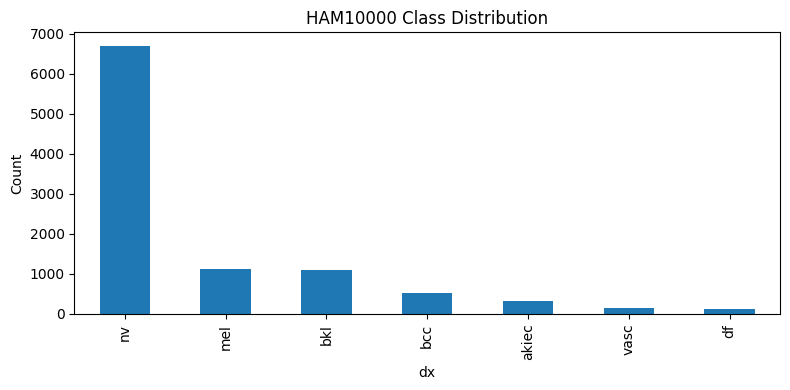

In [14]:
# Class distribution
plt.figure(figsize=(8,4))
df["dx"].value_counts().plot(kind="bar")
plt.title("HAM10000 Class Distribution"); plt.ylabel("Count"); plt.tight_layout(); plt.show()


In [15]:
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(history["train_acc"], label="train"); axes[0].plot(history["val_acc"], label="val")
    axes[0].set_title(f"{title} — Accuracy"); axes[0].legend()
    axes[1].plot(history["train_loss"], label="train"); axes[1].plot(history["val_loss"], label="val")
    axes[1].set_title(f"{title} — Loss"); axes[1].legend()
    plt.tight_layout(); plt.show()


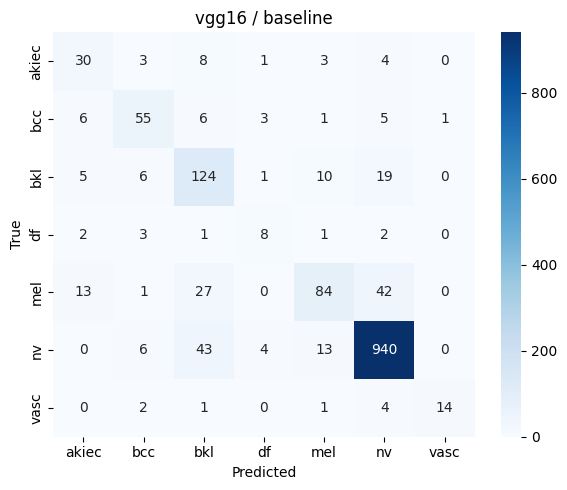

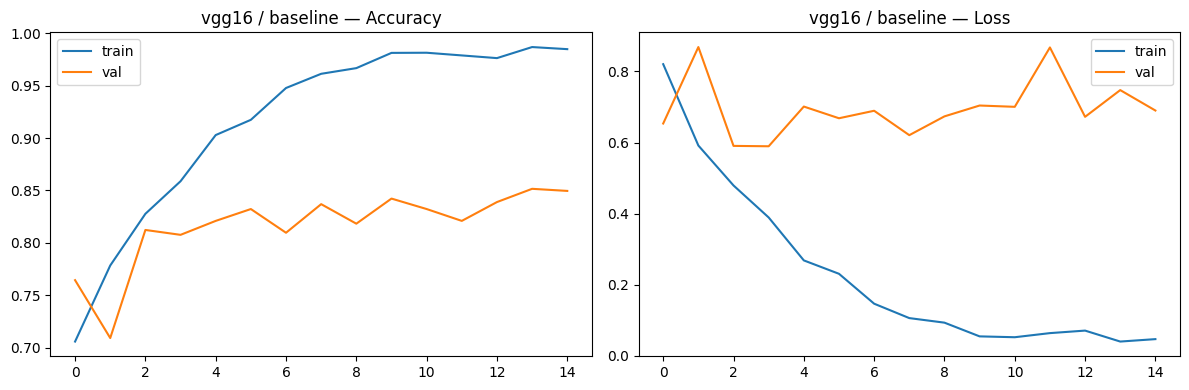

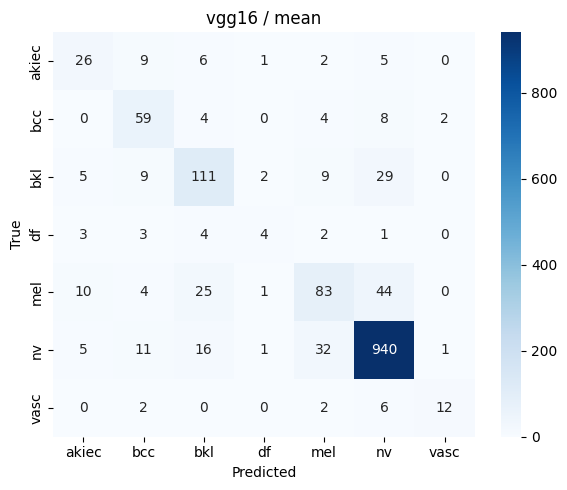

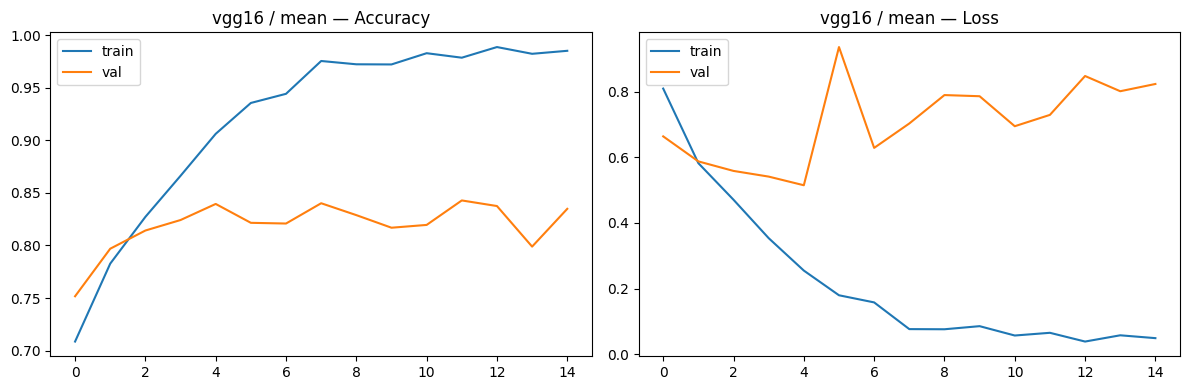

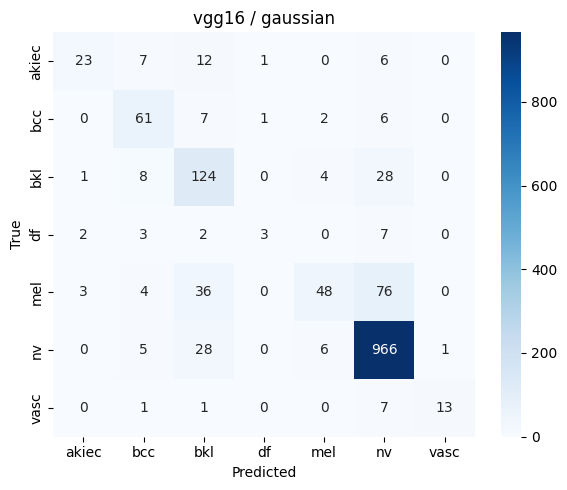

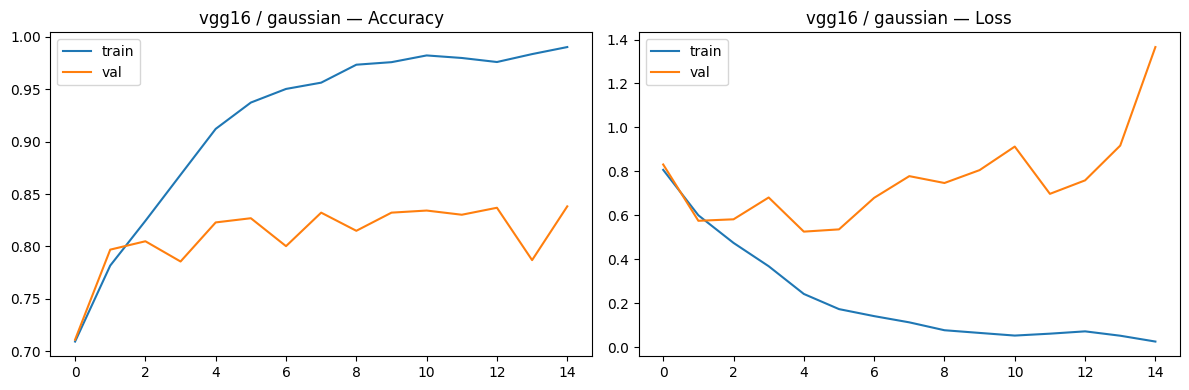

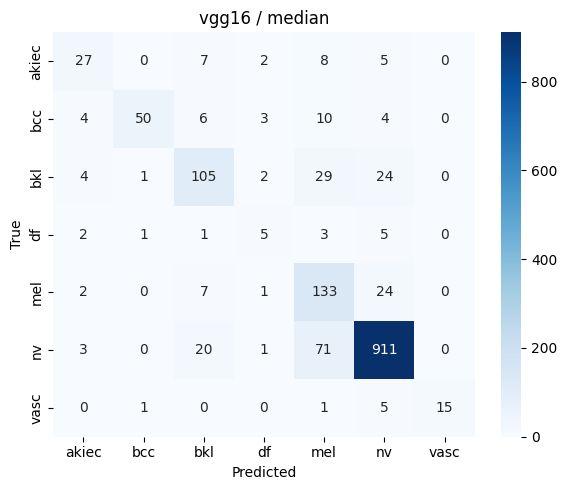

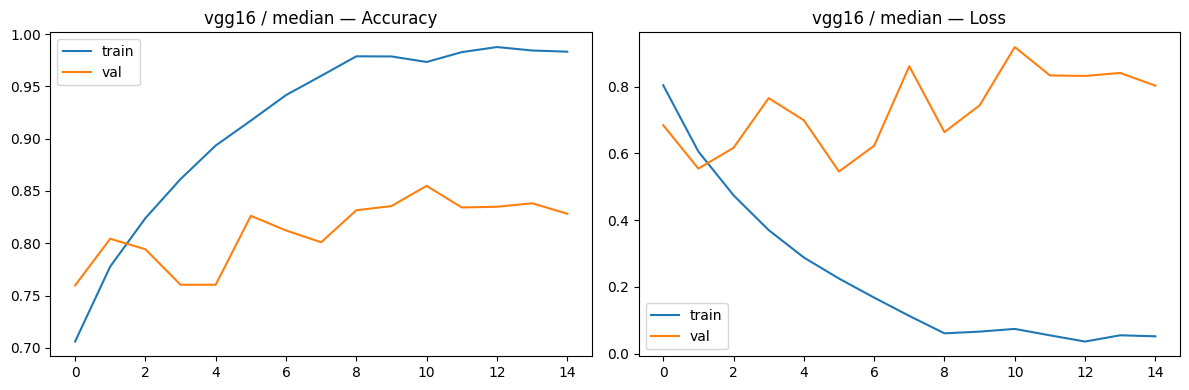

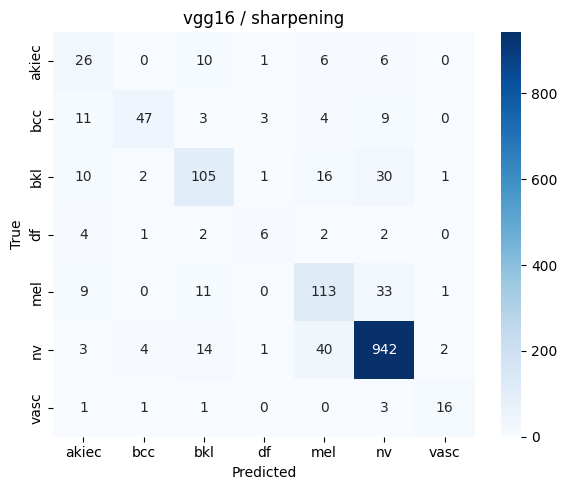

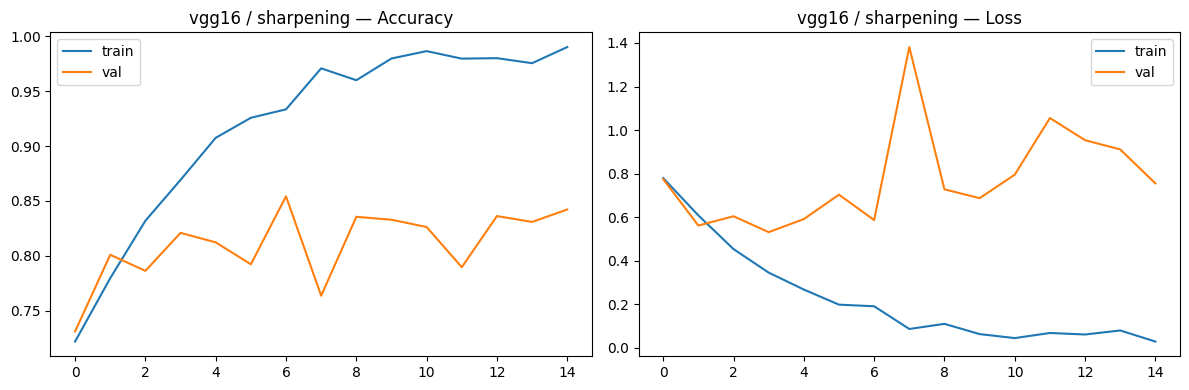

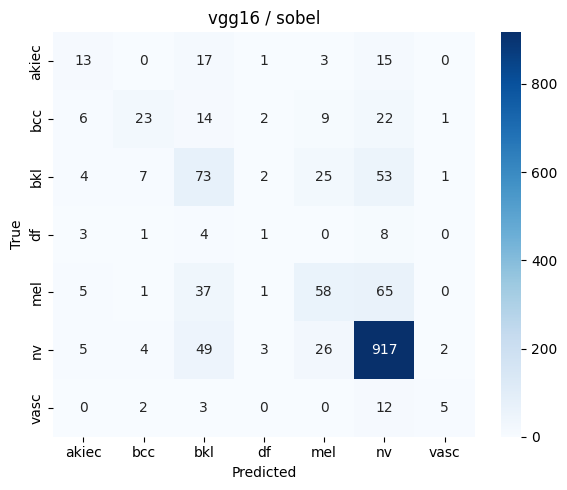

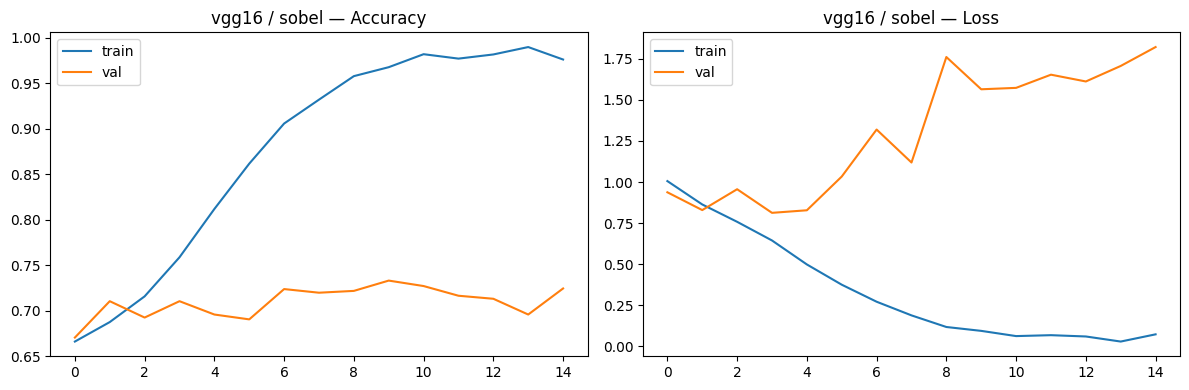

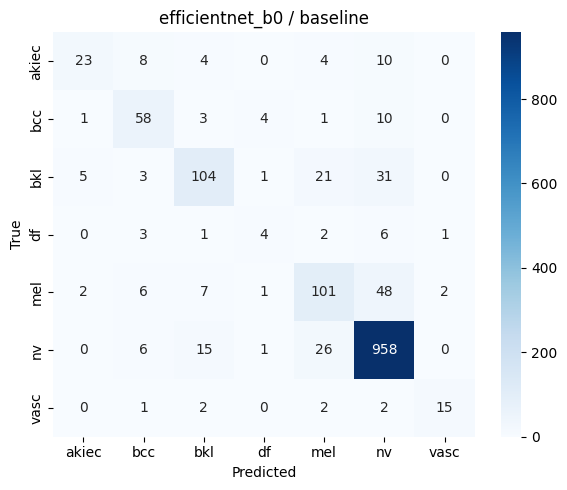

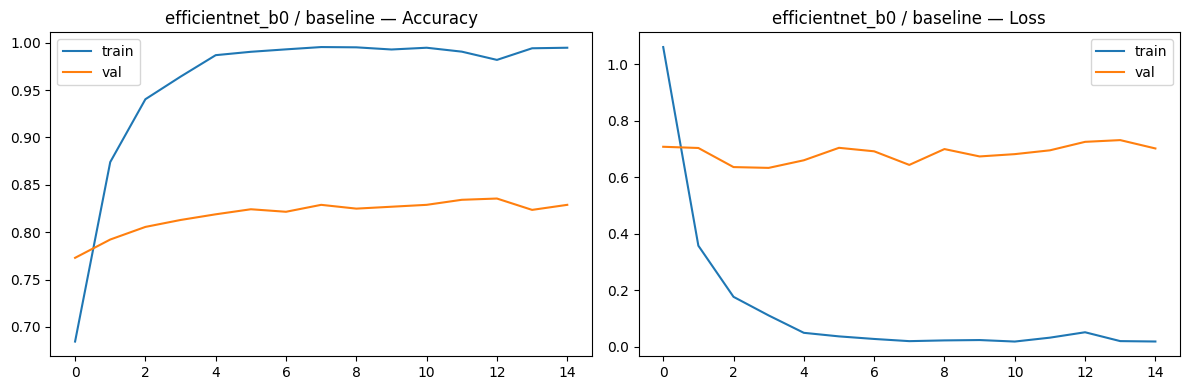

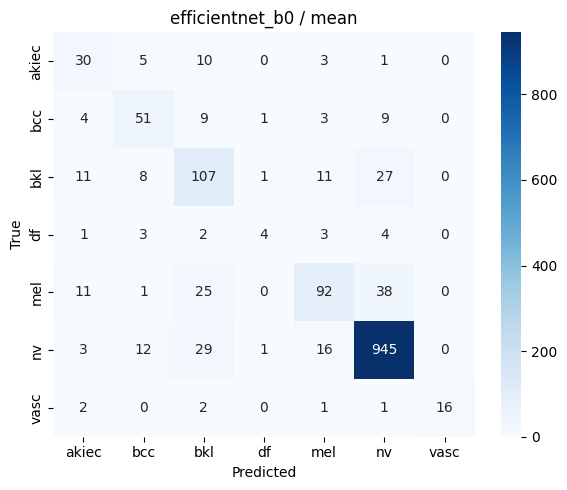

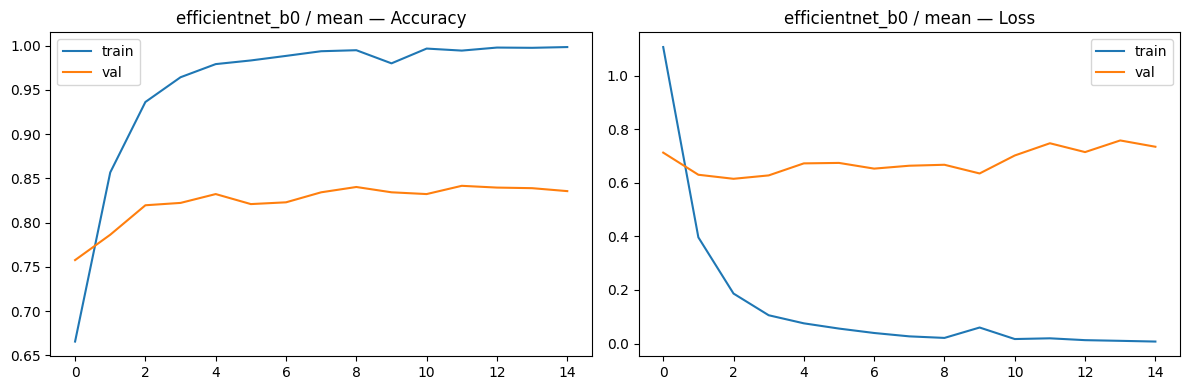

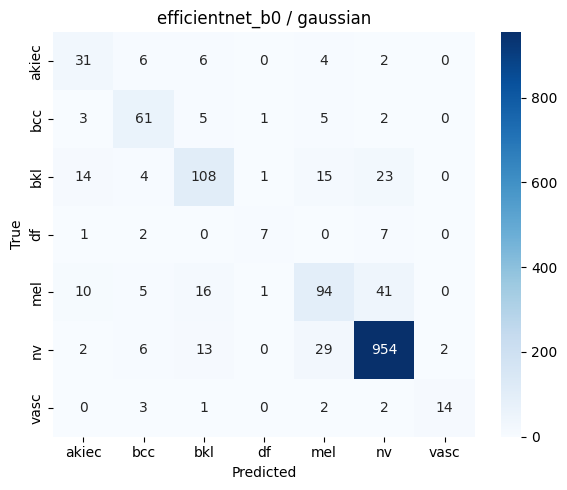

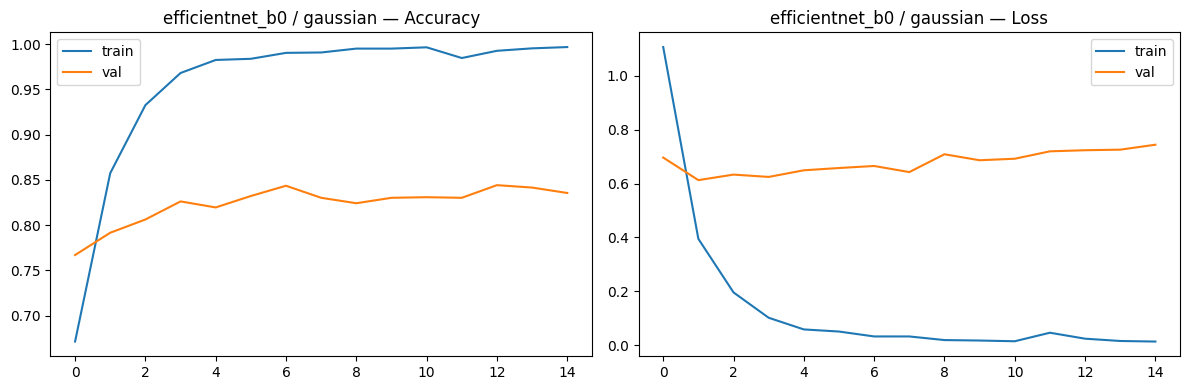

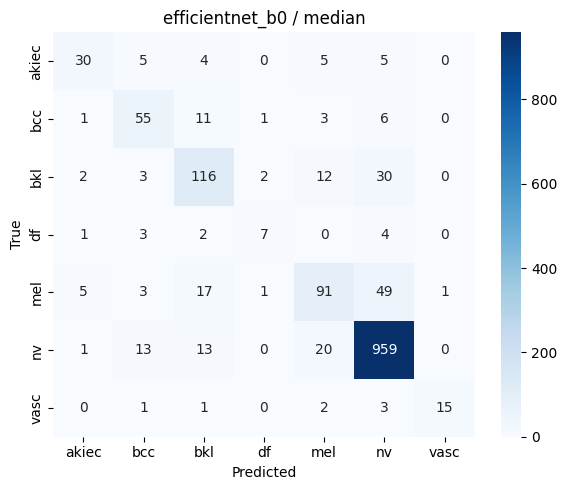

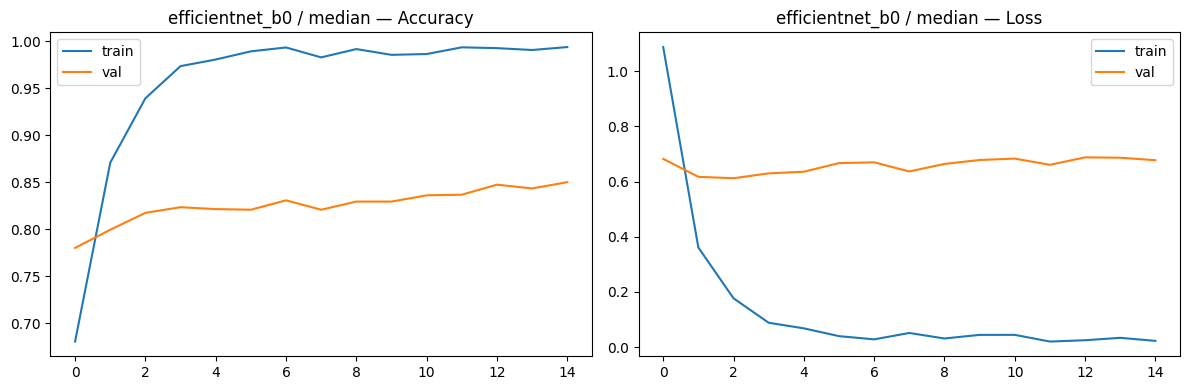

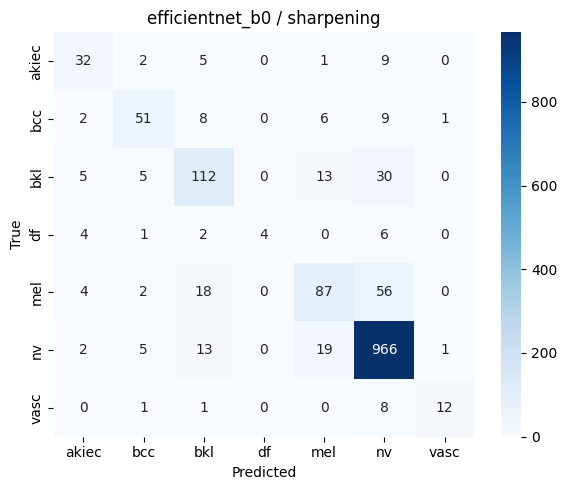

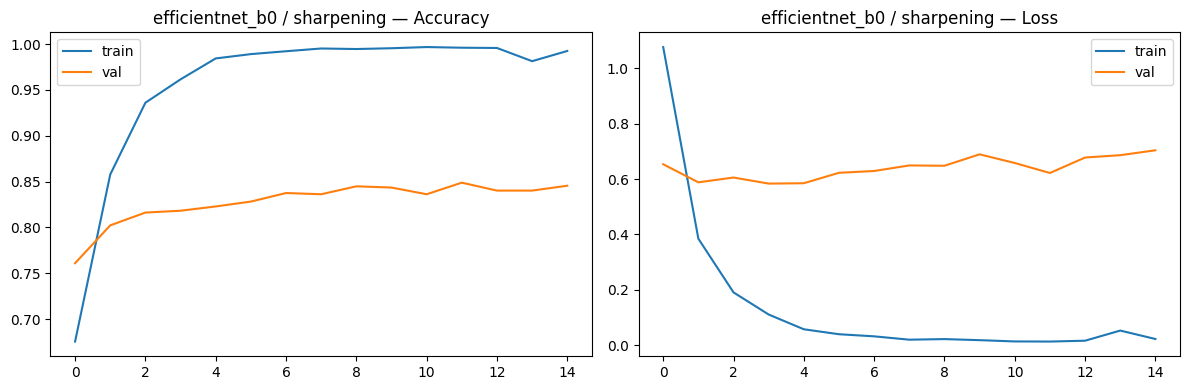

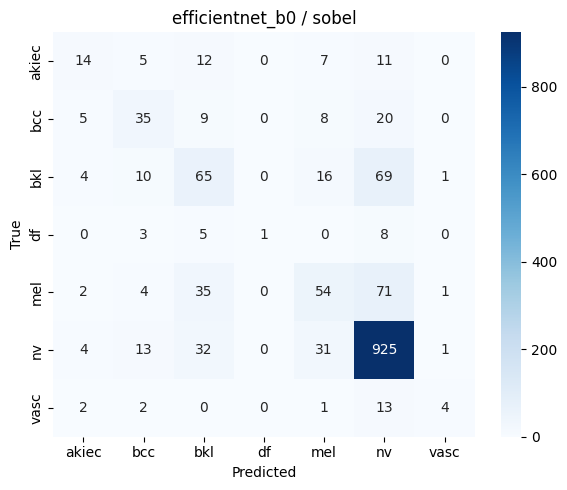

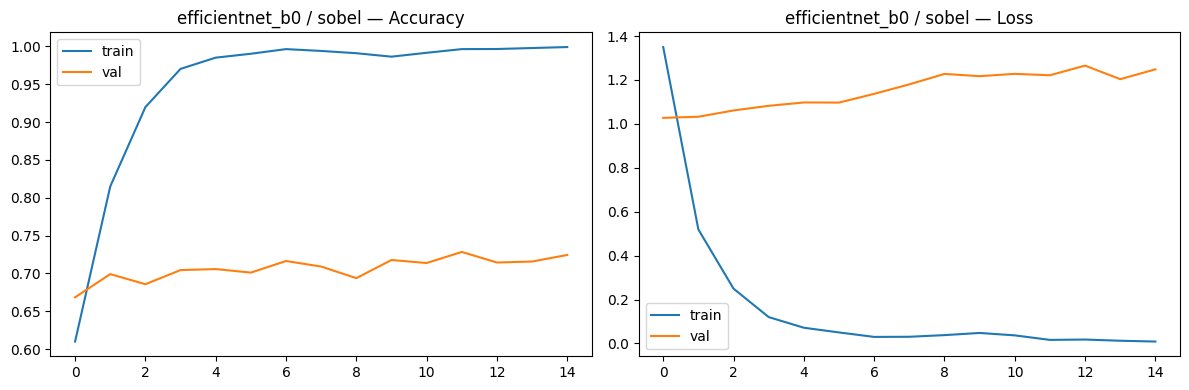

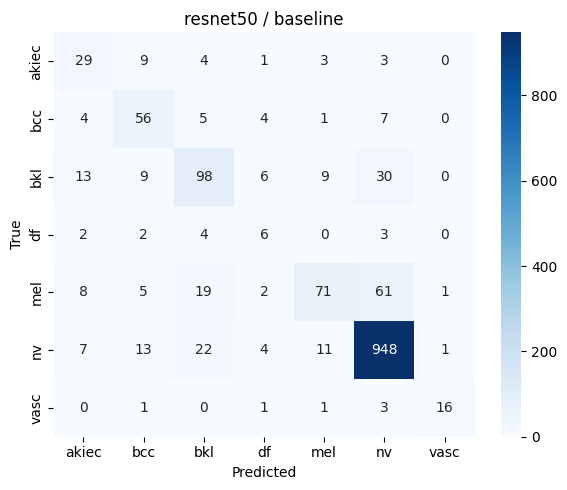

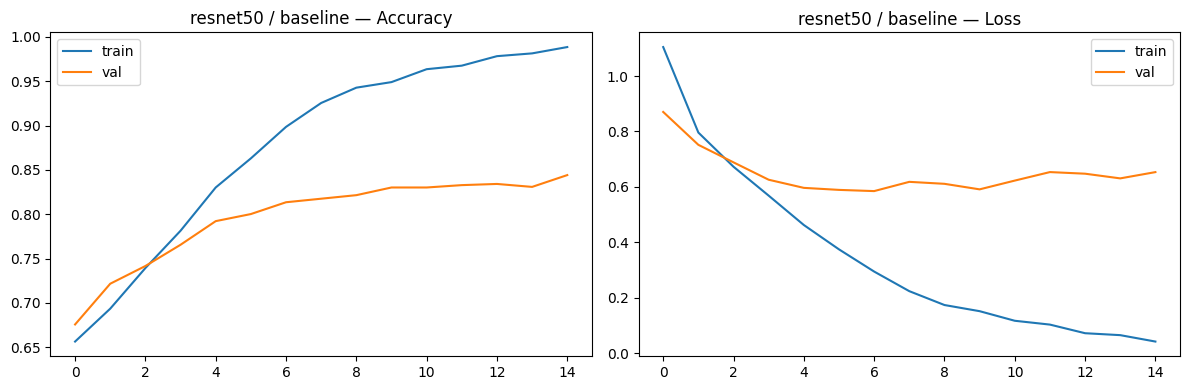

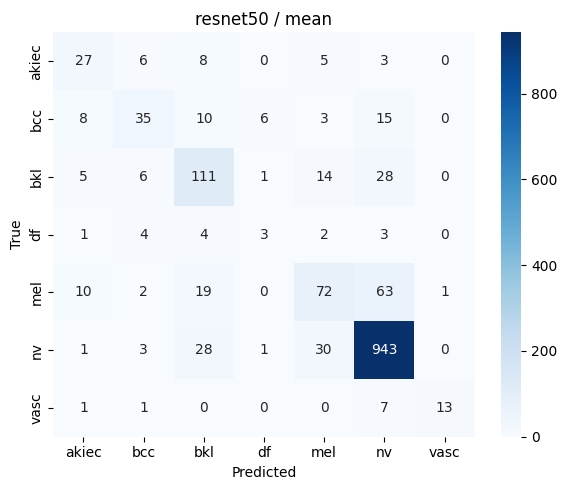

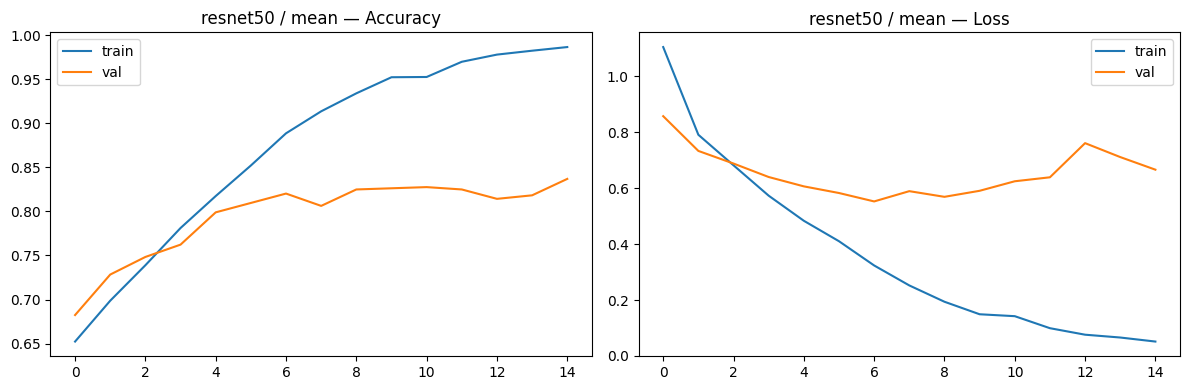

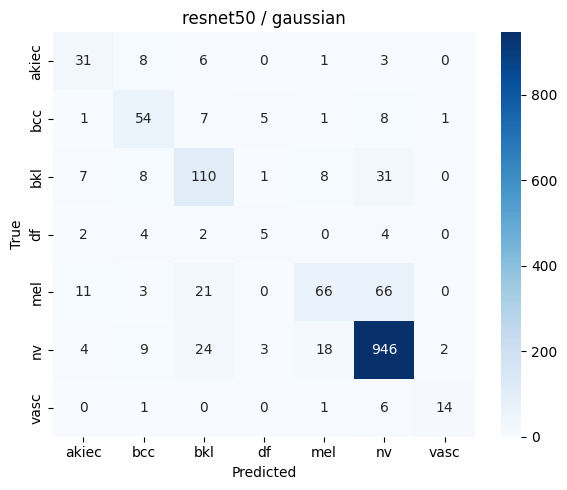

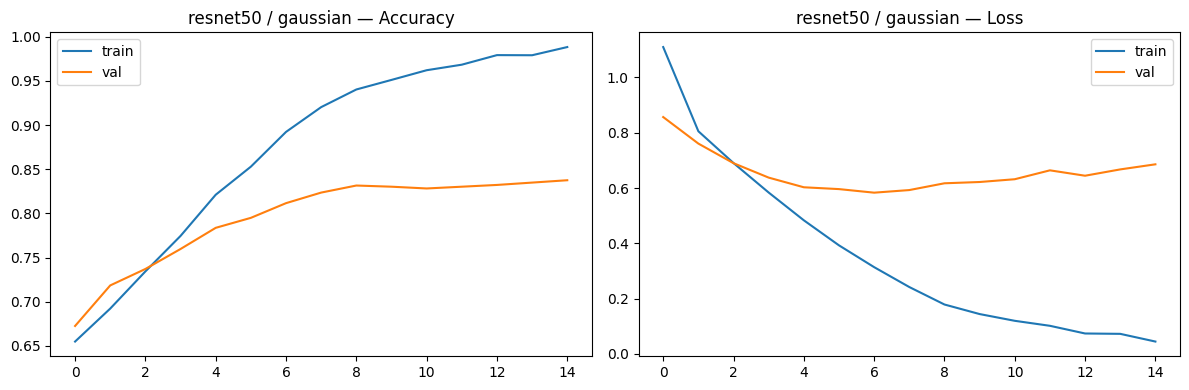

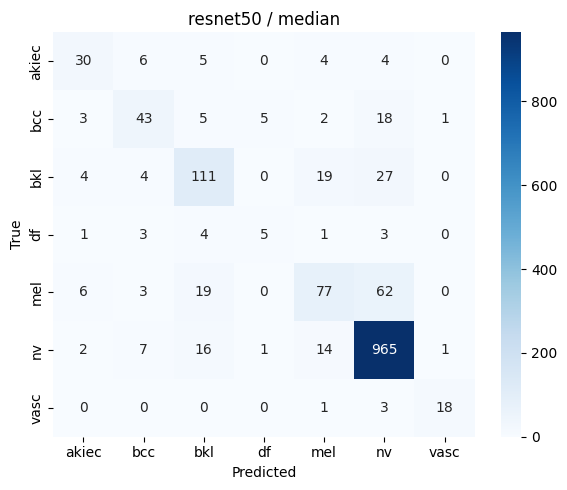

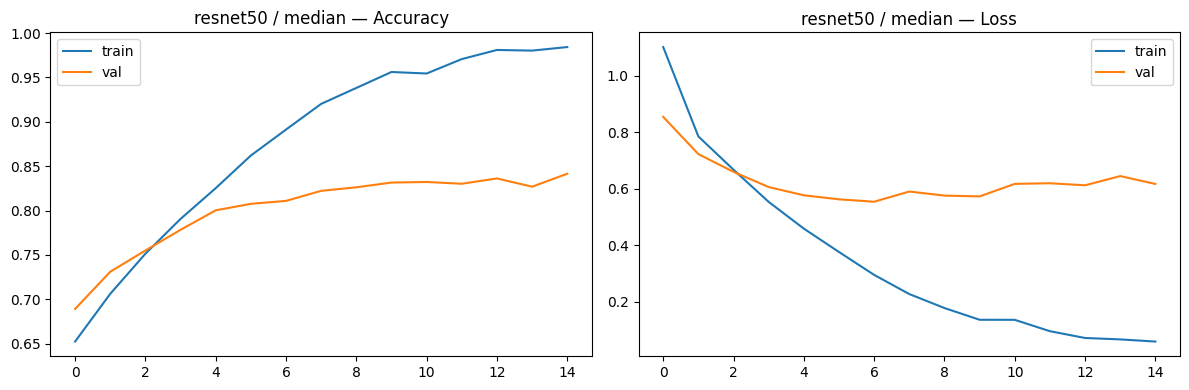

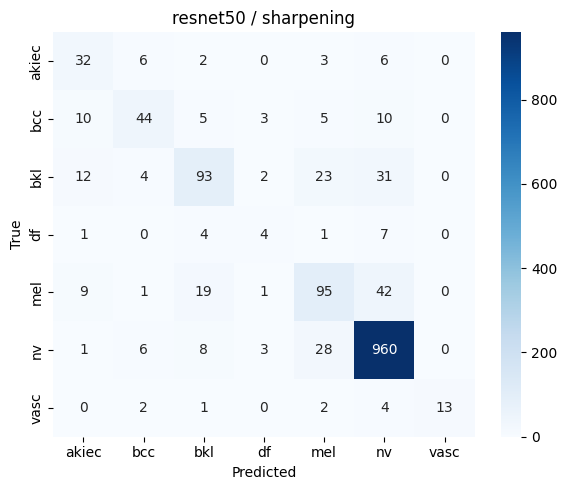

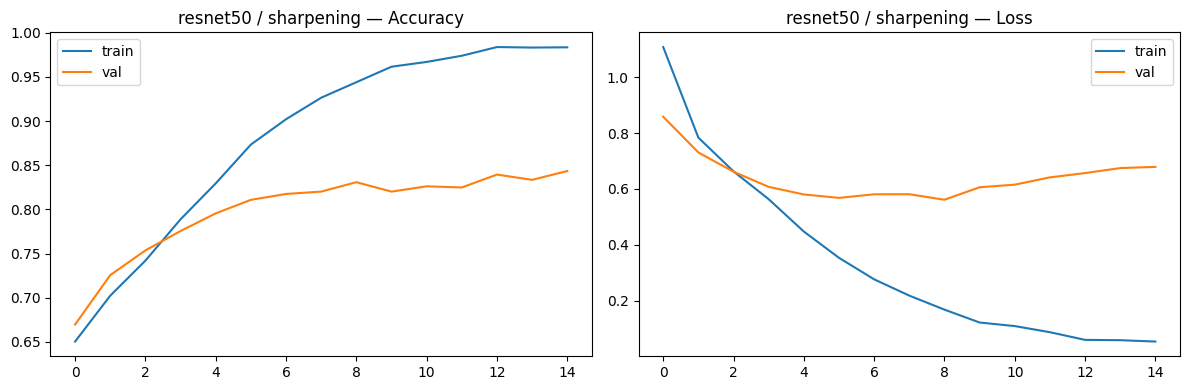

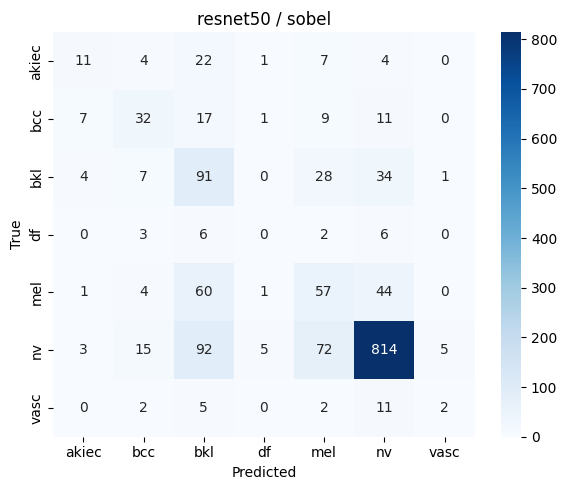

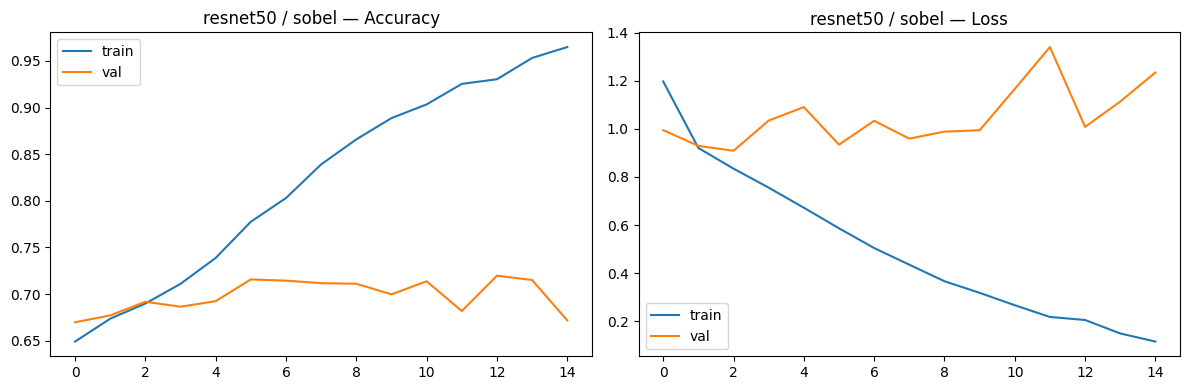

In [16]:
# Plot every run's confusion matrix and curves.
for model_name in MODEL_NAMES:
    for filter_name in FILTERS:
        title = f"{model_name} / {filter_name}"
        plot_confusion_matrix(results[model_name][filter_name]["confusion_matrix"], CLASS_NAMES, title)
        plot_curves(histories[model_name][filter_name], title)


In [17]:
rows = []
for model_name in MODEL_NAMES:
    for filter_name in FILTERS:
        m = results[model_name][filter_name]
        rows.append({
            "model": model_name, "filter": filter_name,
            "macro_f1": round(m["macro_f1"], 4),
            "balanced_accuracy": round(m["balanced_accuracy"], 4),
            "auc": round(m["auc"], 4) if m["auc"] is not None else None,
        })

comparison_df = pd.DataFrame(rows)
comparison_df


,model,filter,macro_f1,balanced_accuracy,auc
0,vgg16,baseline,0.6727,0.6603,0.9455
1,vgg16,mean,0.6156,0.5974,0.9450
2,vgg16,gaussian,0.6176,0.5755,0.9446
3,vgg16,median,0.6743,0.6449,0.9507
4,vgg16,sharpening,0.6572,0.6387,0.9473
5,vgg16,sobel,0.3975,0.3645,0.8507
6,efficientnet_b0,baseline,0.6523,0.6182,0.9558
7,efficientnet_b0,mean,0.6473,0.6251,0.9549
8,efficientnet_b0,gaussian,0.6832,0.6627,0.9591
9,efficientnet_b0,median,0.6990,0.6602,0.9611


In [18]:
# Per-model: how much each filter shifts macro-F1 vs that model's own baseline
for model_name in MODEL_NAMES:
    base_f1 = results[model_name]["baseline"]["macro_f1"]
    print(f"\n{model_name} (baseline macro-F1 = {base_f1:.4f}):")
    for filter_name in FILTERS:
        if filter_name == "baseline":
            continue
        delta = results[model_name][filter_name]["macro_f1"] - base_f1
        print(f"  {filter_name:<12} macro-F1 delta: {delta:+.4f}")



vgg16 (baseline macro-F1 = 0.6727):
  mean         macro-F1 delta: -0.0571
  gaussian     macro-F1 delta: -0.0551
  median       macro-F1 delta: +0.0016
  sharpening   macro-F1 delta: -0.0155
  sobel        macro-F1 delta: -0.2751

efficientnet_b0 (baseline macro-F1 = 0.6523):
  mean         macro-F1 delta: -0.0051
  gaussian     macro-F1 delta: +0.0309
  median       macro-F1 delta: +0.0467
  sharpening   macro-F1 delta: +0.0075
  sobel        macro-F1 delta: -0.2436

resnet50 (baseline macro-F1 = 0.6200):
  mean         macro-F1 delta: -0.0435
  gaussian     macro-F1 delta: +0.0035
  median       macro-F1 delta: +0.0365
  sharpening   macro-F1 delta: +0.0002
  sobel        macro-F1 delta: -0.2709


## Comparative Analysis — Written Answers

**Final results (macro-F1 / balanced accuracy / AUC) — all 18 runs:**

| Model | Filter | Macro-F1 | Balanced Acc. | AUC |
|---|---|---|---|---|
| vgg16 | baseline | 0.6727 | 0.6603 | 0.9455 |
| vgg16 | mean | 0.6156 | 0.5974 | 0.9450 |
| vgg16 | gaussian | 0.6176 | 0.5755 | 0.9446 |
| vgg16 | median | 0.6743 | 0.6449 | 0.9507 |
| vgg16 | sharpening | 0.6572 | 0.6387 | 0.9473 |
| vgg16 | sobel | 0.3975 | 0.3645 | 0.8507 |
| efficientnet_b0 | baseline | 0.6523 | 0.6182 | 0.9558 |
| efficientnet_b0 | mean | 0.6473 | 0.6251 | 0.9549 |
| efficientnet_b0 | gaussian | 0.6832 | 0.6627 | 0.9591 |
| efficientnet_b0 | median | **0.6990** | 0.6602 | **0.9611** |
| efficientnet_b0 | sharpening | 0.6598 | 0.6080 | 0.9576 |
| efficientnet_b0 | sobel | 0.4087 | 0.3740 | 0.8373 |
| resnet50 | baseline | 0.6200 | 0.6230 | 0.9438 |
| resnet50 | mean | 0.5765 | 0.5449 | 0.9352 |
| resnet50 | gaussian | 0.6234 | 0.6095 | 0.9418 |
| resnet50 | median | 0.6564 | 0.6251 | 0.9498 |
| resnet50 | sharpening | 0.6202 | 0.5911 | 0.9476 |
| resnet50 | sobel | 0.3491 | 0.3476 | 0.8105 |

![Results comparison](results_comparison.png)

1. **Which three pretrained models performed best in Lab Activity 1?** — `vgg16`, `efficientnet_b0`, `resnet50` (highest F1-score / AUC in Lab 1).

2. **How does filtering affect each of the three models?** — All three degrade sharply under Sobel. Beyond that they diverge: **vgg16** is hurt by both smoothing filters (mean −0.057, gaussian −0.055) and mildly by sharpening (−0.016), staying flat only under median (+0.002). **efficientnet_b0** is the most robust/filter-tolerant — gaussian (+0.031), median (+0.047), and sharpening (+0.008) all improve on its baseline; only mean is slightly negative (−0.005). **resnet50** sits in between — mean hurts (−0.044), gaussian/sharpening are roughly flat, and median helps (+0.037).

3. **Which filter produces the greatest change vs. the unfiltered baseline?** — **Sobel**, by a large margin, for every model (macro-F1 drop of −0.24 to −0.28, AUC falling from ~0.94–0.96 to ~0.81–0.85). No other filter comes close.

4. **Does the effect of a filter remain consistent across all three models?** — Partially. **Sobel** is consistently very harmful and **median** is consistently neutral-to-helpful across all three models — both directions agree everywhere. **Mean** is consistently negative or flat (never helps). **Gaussian**, however, flips sign: it hurts vgg16 (−0.055) but helps efficientnet_b0 and resnet50 (+0.031, +0.004) — the one filter whose effect isn't model-consistent.

5. **Does filtering improve or decrease macro-F1 and balanced accuracy?** — On balance it decreases performance (driven mainly by Sobel's large drop), but **median** is the exception — it improves or holds macro-F1 for all three models (the only filter that never hurts), making it the best-performing filter overall, even edging out the unfiltered baseline for efficientnet_b0 (0.6990 vs 0.6523) and resnet50 (0.6564 vs 0.6200). Balanced accuracy tracks macro-F1 closely in the same pattern.

6. **Which lesion classes are most affected by filtering?** — Comparing vgg16's baseline vs. Sobel confusion matrices: the minority classes collapse hardest — **df** recall drops from 47% to 6%, **vasc** from 64% to 23%, **bcc** from 71% to 30%, and **akiec** from 61% to 27% — while the majority class **nv** barely moves (93% → 91%). Since macro-F1 weights all classes equally, this disproportionate collapse of low-sample classes is the main driver of Sobel's large macro-F1 drop.

7. **Why might smoothing remove useful lesion texture/morphological information?** — Smoothing blurs high-frequency detail — exactly what carries lesion diagnostic cues (border irregularity, texture, pigment pattern). Lesions start looking more alike, making classification harder.

8. **Why might sharpening or edge detection help or hurt classification?** — Sharpening boosts edges/texture (can help) but also boosts noise/artifacts like hair or ruler marks (can hurt) — consistent with its small, model-dependent effect above. Sobel keeps only edges and drops color/texture — features pretrained ImageNet models depend on — so it hurts substantially and consistently, as seen in every run.

9. **Difference between convolution and correlation?** — Correlation slides the kernel as-is; convolution flips the kernel 180° first, then slides it. Same result for symmetric kernels (Gaussian, Mean), different for asymmetric ones (Sobel). Note: PyTorch/TensorFlow "Conv" layers actually do correlation internally.

10. **Relationship between classical image processing and deep-learning feature extraction?** — Classical filters are fixed, hand-designed. CNNs learn similar low-level filters themselves in early layers, then build abstract features on top. Pre-filtering can clash with what a pretrained backbone learned on natural images — the large, consistent Sobel drop across all three models and all minority classes is direct evidence of that clash.
